# Code of CALC analysis 
based on Learn the code - Part 3

---
**Purpose:** 
- evaluate the CALC data used on Wang et al., 2022
- leran the code modification.

In [1]:
import os

from gnssrefl.utils import check_environment, set_environment, get_sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# Making sure environment variables are set - this is required to run the gnssrefl code
notebook_dir = Path.cwd().parents[0]

exists = check_environment()
if exists == False:
    #If you are running this locally - make sure the items in the exe folder have execution permissions
    set_environment(
        refl_code=str(notebook_dir),
        orbits=str(notebook_dir / "orbits"),
        exe=str(notebook_dir / "exe")
    )


# Set local variable of refl_code location
refl_code_loc = os.environ['REFL_CODE']
orbit_loc = os.environ['ORBITS']
exe_loc = os.environ['EXE']
print("refl_code location:", refl_code_loc)
print("orbits location:", orbit_loc) # 多分これはFilesの中にある軌道情報を参照する予定
print("exe location:", exe_loc)

# import gnssrefl functions
from gnssrefl.rinex2snr_cl import rinex2snr
from gnssrefl.quickLook_cl import quicklook
from gnssrefl.gnssir_input import make_gnssir_input
from gnssrefl.gnssir_cl import gnssir
from gnssrefl.daily_avg_cl import daily_avg
from gnssrefl.installexe_cl import installexe

# cut-off functions
from gnssrefl.cutoff_beckmann import (
    precompute_sigma_grid,
    plot_sigma_vs_epsilon,
    swh_from_T_eps,
)
from gnssrefl.cutoff_swh import process_station_for_swh
from gnssrefl.cutoff_wind_direction import plot_wind_polar

#@formatter:off
%matplotlib inline

refl_code location: /etc/gnssrefl/refl_code
orbits location: /etc/gnssrefl/refl_code
exe location: /etc/gnssrefl/exe


In [10]:
# Download the executables
try:
    os.environ['DOCKER']
except KeyError:
    sys = get_sys()
    installexe(sys)

**Station:**
- Station **CALC** (Calcasieu Pass). 
- Check the [map](https://maps.app.goo.gl/dS8WFdh5JNjW21pz6)

**Azimuth/Elevation Mask**

Get an idea of what this site looks like from a reflections viewpoint. 

In [11]:
# save the variable for the station name since it will be used for the rest of the notebook
station = 'calc'

# fill in the values for these variables from the output of the web app below
lat = 29.76813859
long = -93.34288999
height = -15.18

In [ ]:
%%html
<iframe src="https://gnss-reflections.org/geoid" width="1000" height="600"></iframe>

Use the [reflection zone section of the web app](https://gnss-reflections.org/rzones) in the cell below to get an idea
of what reflection zones are possible for this site. We cannot use the default sea level reflection 
value, so you need to set a Reflector Height (RH) value. Based on the photograph, try values that
you think are reasonable. You don't want your reflection zones to cross 
a dock or the nearby boats, so you should also rerun it with different azimuth limits. Don't worry about it too much as we will get feedback from the actual GPS data.

Make a note of:

<UL>
<LI>RH
<LI>elevation angle values that give water coverage without interference from docks/boats
<LI>azimuth angle values that cover open water without interference
<LI>the DECIMAL latitude, longitude, and height (from the geoid webapp).
<LI>we can only use L1 GPS data at this site 
<LI>We can't estimate RH larger than 10 meters because of the sampling rate
</UL>

In [4]:
%%html
<iframe src="https://gnss-reflections.org/rzones" width="800" height="800"></iframe>

command `refl_zones` also can generate the kml file of reflectometry.

**Using gnssrefl**

Now let's look at the **calc** data. We need to pick up a RINEX file and strip out the 
SNR data.  We use the <code>rinex2snr</code> for this purpose.  Use -h if you want to 
see the options for this module. We will throw caution to the winds and see if the defaults will work. 
The only required inputs are the station name (calc), the year (2020) and day of year (150) 
(note: to convert from year and day of year to year, 
month, day and vice versa, try the modules <code>ydoy</code> and 
<code>ymd</code>). 

In this case the RINEX data are available from both sopac and nrcan. Try the <code>archive</code> option.

In [2]:
rinex2snr?

Signature:
rinex2snr(
    station: str,
    year: int,
    doy: int,
    snr: str = None,
    orb: str = None,
    rate: str = 'low',
    dec: int = 0,
    nolook: bool = False,
    archive: str = 'all',
    doy_end: int = None,
    year_end: int = None,
    overwrite: bool = False,
    translator: str = 'hybrid',
    samplerate: int = 30,
    stream: str = 'R',
    mk: bool = False,
    weekly: bool = False,
    strip: bool = False,
    screenstats: bool = False,
    gzip: bool = True,
    monthly: bool = False,
    par: int = None,
    timeout: int = 0,
    extension: str = '',
    debug: bool = False,
    quiet: bool = True,
)
Docstring:
Note: rinex2snr means rinex TO snr. It is not a tool that is only meant for version 2 rinex files.

rinex2snr translates RINEX version 2.11 and 3+ files to a new file in 
the SNR format. This function will also fetch orbit files for you.
RINEX obs files are provided either by the user or fetched from a 
long list of archives. Although RINEX 3 is sup

In [60]:
year = 2020
doy = 277
doy_end = 288
# if you would like to pick an archive then you can 
# archive = 'nrcan'
# archive = 'sopac'

# if you choose to use an archive then you must add the parameter archive example:
# args = run_gnssrefl.rinex2snr(station, year, doy, archive=archive)

# otherwise, the only required parameters are station, year, and doy
# rinex2snr(station, year, doy, nolook=True)
rinex2snr(station, year, doy, doy_end=doy_end, snr=88, nolook=True)

Using JSON file: /etc/gnssrefl/refl_code/input/calc/calc.json
Using snr value of  88
Using default orbit for this time period:  nav
Using archive value of  all
Station  calc  has four characters, assume RINEX 2.11 format
No parallel processing
SNR file does not already exist. Which means I will try to make it.
calc 2020 277
Fortran translation log:  /etc/gnssrefl/refl_code/logs/calc/2020/277_translation.txt
General log:  /etc/gnssrefl/refl_code/logs/calc/2020/277_translation.txt.gen
Will first assume station  calc  year: 2020  doy: 277 is located here : /usr/src/gnssrefl/notebooks/Dev/Wind_Direction
Looked for  /usr/src/gnssrefl/notebooks/Dev/Wind_Direction/calc2770.20o
Failed, will search other names/directories
Looking for file:  /usr/src/gnssrefl/notebooks/Dev/Wind_Direction/calc2770.20o.gz
Looking for file:  /usr/src/gnssrefl/notebooks/Dev/Wind_Direction/calc2770.20o.Z
Looking for file:  /usr/src/gnssrefl/notebooks/Dev/Wind_Direction/calc2770.20d
Now looking for the file in :  /etc

---
Once you have successfully created a SNR file, run <code>quickLook</code>.

In [14]:
quicklook?

Signature:
quicklook(
    station: str,
    year: int,
    doy: int,
    snr: int = 66,
    fr: int = 1,
    ampl: float = 7.0,
    e1: float = 5,
    e2: float = 25,
    h1: float = 0.5,
    h2: float = 8.0,
    sat: int = None,
    peak2noise: float = 3.0,
    screenstats: bool = False,
    fortran: bool = None,
    plt: bool = True,
    azim1: float = 0.0,
    azim2: float = 360.0,
    ediff: float = 2.0,
    delTmax: float = 75.0,
    hires_figs: bool = False,
)
Docstring:
quickLook assessment of GNSS-IR results using SNR data. It creates two plots: one with periodograms for
four different quadrants (northwest, northeast, southeast, southwest) and the other with the RH
results shown as a function of azimuth. This plot also summarizes why the RH retrievals were accepted
or rejected in terms of the quality control parameters.  

Examples
--------
quickLook p041 2023 1 
    analyzes station p041 on day of year 1 in the year 2023 with defaults (L1, e1=5, e2=25)

quickLook p041 2023 1 -

fr: used Signal frequency
| 衛星系     | 周波数           | `-fr` の値 | 備考                   |
| ------- | ------------- | -------- | -------------------- |
| GPS     | L1            | **1**    | default of quickLook     |
| GPS     | L2            | 2        | include of old L2P           |
| GPS     | L2C           | 20       | desirable if possible         |
| GPS     | L5            | 5        | high chip rate. Disadvantage when high RH   |
| GLONASS | L1            | 101      |                      |
| GLONASS | L2            | 102      |                      |
| Galileo | E1            | 201      |                      |
| Galileo | E5a           | 205      |                      |
| Galileo | E6            | 206      |                      |
| Galileo | E5b           | 207      |                      |
| Galileo | E5 (E5ab)     | 208      | It might not be analisable where tall site    |
| BeiDou  | B1 (1561 MHz) | 302      |                      |
| BeiDou  | B2 (1207 MHz) | 306      |                      |
| BeiDou  | B3 (1268 MHz) | 307      | 301,305,308 ... |

ampl: threshold of signal amplitude.

ediff: The elevation angle range covered by the satellite.

delTmax: How long we should a single satellite arc be permitted to extend. [min]

hires_figs: if flaged, the high-resolution image(EPS format) will be outputed.

minimum elevation angle (degrees) for this dataset:  4.8713
Plot saved to  /etc/gnssrefl/refl_code/Files/calc/quickLook_lsp.png
Plot saved to  /etc/gnssrefl/refl_code/Files/calc/quickLook_summary.png


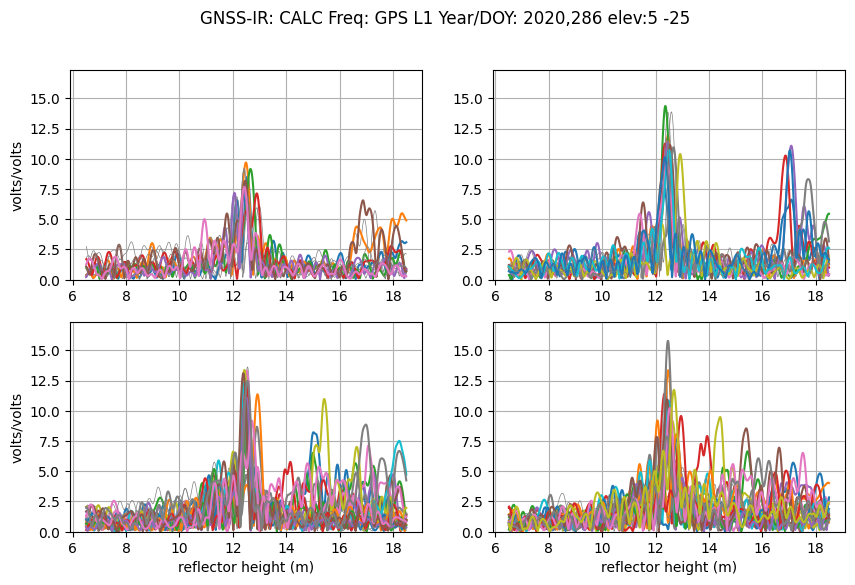

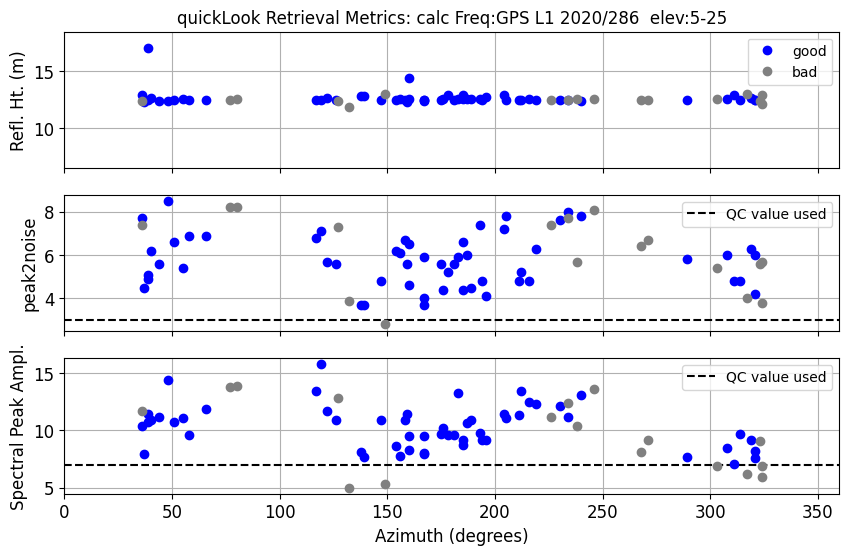

In [15]:
# Plotting using plt=True
doy_med = 286
values, metrics = quicklook(station, year, doy=doy_med, h1=6.5, h2=18.5, plt=True)

Evaluation of peak2noise
- Signal-to-Noise ratio of the LSP peak. Noise is considered as median value of Lomb-Scargle (LSP).
- emperically, 2.7 is good for tide estimation
Evalustion of Spectral Peak Ampl.
- maximum power in LSP
- Peak of the reflected elevation spectrum obtained from the detrended SNR(t)

From these plots, how does the correct *RH* value compare with the one you assumed earlier when you 
were trying out the webapp?  How about the azimuths?  Go back to the reflection zone webapp and 
make sure you are happy with your azimuth and elevation angle selections.

Next we need to save our <code>gnssrefl</code> analysis strategy using 
<code>make_json_input</code>. At a minimum you need to know 
the latitude, longitude, and height for the station (we saved these as variables earlier so they can easily be accessed at this point). However, your analysis strategy can and should
be improved by setting some parameters.

*Hints:*

* Check the documentation to see how to set the elevation angles and RH limits. You can run the following cell to see the parameters.

* Since we can only use L1 data, you should use the <code>l1=True</code>.

* You will need to hand edit the azimuths in the json file. You want to cut up your azimuth range in 60-90 degree chunks.  So if you wanted to use the region  for 90-270 degrees, you should say 90-180 and 180-270. You can use smaller chunks, but I generally do not use less than 45 degree azimuth chunks.

In [16]:
# run this cell to view the available parameters and current defaults
make_gnssir_input?

Signature:
make_gnssir_input(
    station: str,
    lat: float = 0,
    lon: float = 0,
    height: float = 0,
    e1: float = 5.0,
    e2: float = 25.0,
    h1: float = 0.5,
    h2: float = 8.0,
    nr1: float = None,
    nr2: float = None,
    peak2noise: float = 2.8,
    ampl: float = 5.0,
    allfreq: bool = False,
    l1: bool = False,
    l2c: bool = False,
    l5: bool = False,
    xyz: bool = False,
    refraction: bool = True,
    extension: str = '',
    ediff: float = 2.0,
    delTmax: float = 75.0,
    frlist: list = [],
    azlist2: list = [0, 360],
    ellist: list = [],
    refr_model: str = '1',
    apriori_rh: float = None,
    Hortho: float = None,
    pele: list = [5, 30],
    polyV: int = 4,
    daily_avg_reqtracks: int = None,
    daily_avg_medfilter: float = None,
    subdaily_alt_sigma: bool = None,
    subdaily_ampl: float = None,
    subdaily_delta_out: float = None,
    subdaily_knots: int = None,
    subdaily_sigma: float = None,
    subdaily_subdir: str = No

In [17]:
make_gnssir_input(station, lat, long, height, h1=6.5, h2=18.5, l1=True, azlist2=[-140, 70])

If you plan to use the NITE refraction model you should choose a better a priori 
Reflector Height. Currently using the default which is not necessarily relevant
for your site. Hortho value can be used for coastal sites, but not for interior lakes/rivers.

Using default DC removal elevation angle limits, 5 30
Checking that they are sensible
Using standard frequency choices.
refraction model  1
writing json file to:  /etc/gnssrefl/refl_code/input/calc/calc.json


- l1, l2c, l5 : shortcut flag for only use gps.
- If you use GALILEO, GLONASS or BDS, you must use frlist option or turn on allfreq flag.

In [18]:
# This is the json file that was created with the defaults + parameters you set above
json_file = f'{refl_code_loc}/input/{station}/{station}.json'
print(json_file)
with open(json_file, "r") as myfile:
    file = json.load(myfile)

file

/etc/gnssrefl/refl_code/input/calc/calc.json


{'station': 'calc',
 'lat': 29.76813859,
 'lon': -93.34288999,
 'ht': -15.18,
 'Hortho': 12.46,
 'apriori_rh': 5,
 'minH': 6.5,
 'maxH': 18.5,
 'e1': 5.0,
 'e2': 25.0,
 'NReg': [6.5, 18.5],
 'PkNoise': 2.8,
 'polyV': 4,
 'pele': [5, 30],
 'ediff': 2.0,
 'desiredP': 0.005,
 'azval2': [-140, 70],
 'freqs': [1],
 'reqAmp': [5.0],
 'refraction': True,
 'overwriteResults': True,
 'seekRinex': False,
 'wantCompression': False,
 'plt_screen': False,
 'onesat': None,
 'screenstats': False,
 'pltname': 'calc_lsp.png',
 'delTmax': 75.0,
 'gzip': False,
 'ellist': [],
 'refr_model': 1,
 'daily_avg_reqtracks': None,
 'daily_avg_medfilter': None,
 'subdaily_alt_sigma': None,
 'subdaily_ampl': None,
 'subdaily_delta_out': None,
 'subdaily_knots': None,
 'subdaily_sigma': None,
 'subdaily_spline_outlier1': None,
 'subdaily_spline_outlier2': None,
 'subdaily_subdir': None,
 'stream': None,
 'samplerate': None,
 'snr': None,
 'dec': None}

In [19]:
# Now lets edit the json file
with open(json_file, "r") as myfile:
    file = json.load(myfile)

# Here is where we can 'hand edit' values in the json file
# lets edit the azimuths
file['apriori_rh'] = 12.46

with open(json_file, 'w') as f:
    json.dump(file, f, indent=4)

# now lets view it again and note the difference
with open(json_file, "r") as myfile:
    file = json.load(myfile)

file

{'station': 'calc',
 'lat': 29.76813859,
 'lon': -93.34288999,
 'ht': -15.18,
 'Hortho': 12.46,
 'apriori_rh': 12.46,
 'minH': 6.5,
 'maxH': 18.5,
 'e1': 5.0,
 'e2': 25.0,
 'NReg': [6.5, 18.5],
 'PkNoise': 2.8,
 'polyV': 4,
 'pele': [5, 30],
 'ediff': 2.0,
 'desiredP': 0.005,
 'azval2': [-140, 70],
 'freqs': [1],
 'reqAmp': [5.0],
 'refraction': True,
 'overwriteResults': True,
 'seekRinex': False,
 'wantCompression': False,
 'plt_screen': False,
 'onesat': None,
 'screenstats': False,
 'pltname': 'calc_lsp.png',
 'delTmax': 75.0,
 'gzip': False,
 'ellist': [],
 'refr_model': 1,
 'daily_avg_reqtracks': None,
 'daily_avg_medfilter': None,
 'subdaily_alt_sigma': None,
 'subdaily_ampl': None,
 'subdaily_delta_out': None,
 'subdaily_knots': None,
 'subdaily_sigma': None,
 'subdaily_spline_outlier1': None,
 'subdaily_spline_outlier2': None,
 'subdaily_subdir': None,
 'stream': None,
 'samplerate': None,
 'snr': None,
 'dec': None}

Now run <code>gnssir</code> for the year 2020/doy 150. 
This module is meant for *routine analysis* and thus there are not a lot
of bells and whistles. However, it is good practice to see that something is actually 
created (the screen output will tell you where it is).

Using JSON file: /etc/gnssrefl/refl_code/input/calc/calc.json
Using snr file type:  66
dbhz False
[5, 30]  direct signal elevation angle limits
Requested frequencies  [1]
Parallel processing not requested
refraction model 1
LSP Results will be written to: /etc/gnssrefl/refl_code/2020/results/calc/286.txt
Refraction parameters (pressure, temp, humidity, ModelNum) 1015.603 21.444 19.765 1
SNR data were read from:  /etc/gnssrefl/refl_code/2020/snr/calc/calc2860.20.snr66
Min observed elev. angle 4.8713 for calc 2020:286/ Requested e1-e2: of 5.0-25.0
Standard Bennett refraction correction
data found for this frequency:  1
/etc/gnssrefl/refl_code/Files/calc/gnssir_freq001.png
Plot file saved as:  /etc/gnssrefl/refl_code/Files/calc/gnssir_freq001.png


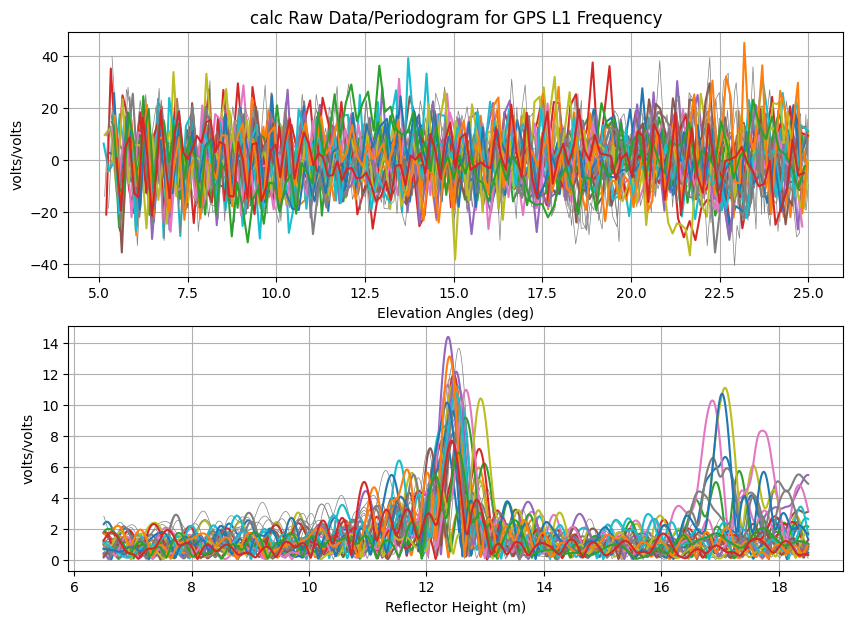

Screen stat information printed to:  /etc/gnssrefl/refl_code/logs/calc/2020/286_gnssir.txt
Writing sorted LSP results to :  /etc/gnssrefl/refl_code/2020/results/calc/286.txt 

Time to compute:  2.48  seconds


In [20]:
year = 2020
doy = 286
gnssir(station, year, doy, plt=True, screenstats=False)

How to evaluate:
- Raw Data (SNR)
    - Low elevation angle: Are smooth, sine-wave-like vibrations visible?
    - Are wavy, sine-wave-like stripes (periodic vibrations) visible relative to the elevation angle?
    - Do most satellites properly traverse the entire elevation angle range from e1 to e2?

# Wave height and direction estimation from cut-off angle
This method is based on Wang et al. (2022).

## Theoretical curve generation

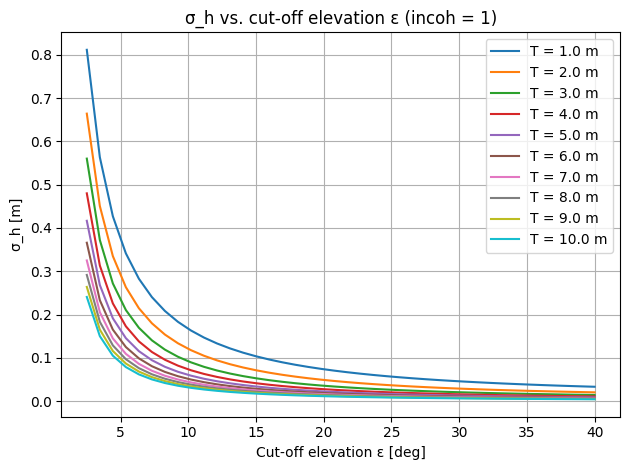

In [2]:
# Example physical parameters
lam = 0.19029367  # GNSS wavelength [m], e.g., GPS L1
h = 12.5          # Antenna height above sea surface [m]

# Define grid
T_values = np.arange(1.0, 11.0, 1.0)     # T = 1–10 m
eps_deg_values = np.linspace(2.5, 40, 40)  # ε = 2.5-40 deg, total points

# Compute sigma_h grid for incoh = 1
sigma_grid = precompute_sigma_grid(
    T_values,
    eps_deg_values,
    lam,
    h
)

# Plot sigma_h vs epsilon for each T
plot_sigma_vs_epsilon(T_values, eps_deg_values, sigma_grid)


In [3]:
# Query SWH for a specific T and cut-off elevation epsilon

T_query = 2.0     # [m]
eps_query = 5  # [deg]

swh_val = swh_from_T_eps(
    T_query,
    eps_query,
    T_values,
    eps_deg_values,
    sigma_grid,
    factor=4.0,   # SWH = 4 * sigma_h (assumed)
)

print(f"T = {T_query:.2f} m, ε = {eps_query:.2f} deg -> SWH ≈ {swh_val:.3f} m")

T = 2.00 m, ε = 5.00 deg -> SWH ≈ 1.168 m


## Wave height estimation

In [4]:
# 相関長の代表値（決め打ち）
T_rep = 2.0   # [m]  ここは好きな値にしてOK

def e_cutoff_upper_to_swh(e_cutoff_upper_deg, azimuth_deg, T_rep_local):
    """
    e_cutoff_upper_deg [deg] → SWH [m]
    """
    if e_cutoff_upper_deg is None or np.isnan(e_cutoff_upper_deg):
        return np.nan

    # swh_from_T_eps(T_query, eps_query, T_values, eps_deg_values, sigma_grid, factor)
    swh_val = swh_from_T_eps(
        T_rep_local,           # T_query
        e_cutoff_upper_deg,    # eps_query
        T_values,
        eps_deg_values,
        sigma_grid,
        4.0,                   # factor = 4.0
    )
    return swh_val


In [13]:
year = 2020           # yyyy
station = "calc"      # ディレクトリ名としての局名

df_swh = process_station_for_swh(
    year=year,
    station=station,
    func_e_to_swh=e_cutoff_upper_to_swh,  # ← さっき作ったラッパ
    base_dir="/etc/gnssrefl/refl_code",
    wavelength=lam,       # GPS L1
    T_rep=T_rep,          # 相関長の代表値（ラッパにも渡る）
    snr_column="L1",      # L1 を使うならこれ。他なら "L2" / "L5"
    e_min=5,
    e_max=40.0,
    min_points=40,
    max_gap_sec=800.0,
    h_min=0.5,
    h_max=20.0,
    num_h=80,
    rh_level=12.5,
    wavelet_name="cmor10.0-5.0",
    output_csv="swh_estimates.csv",  # 波高＋cut-off の結果ファイル
    snr_type="88",
)

df_swh

pattern = *.snr88.gz
Reading snr files:
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2770.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2780.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2790.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2800.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2810.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2820.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2830.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2840.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2850.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2860.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2870.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2880.20.snr88.gz


,year,station,day_index,sat,time_hour,azimuth_deg,e_cutoff_lower_deg,e_cutoff_upper_deg,rh_ref_m,swh_m
0,2020,calc,0,1,0.691667,244.408977,NaN,NaN,12.5,NaN
1,2020,calc,0,1,7.416218,92.783639,5.4639,35.3438,12.5,0.094975
2,2020,calc,0,1,22.675000,297.188078,NaN,NaN,12.5,NaN
3,2020,calc,1,1,0.658333,243.564142,NaN,NaN,12.5,NaN
4,2020,calc,1,1,7.350646,92.725187,16.7608,37.6134,12.5,0.088097
...,...,...,...,...,...,...,...,...,...,...
621,2020,calc,9,32,20.069692,175.977350,5.6233,17.9867,12.5,0.225563
622,2020,calc,10,32,0.637500,109.924655,NaN,NaN,12.5,NaN
623,2020,calc,10,32,20.127833,173.393536,13.6732,19.9558,12.5,0.196973
624,2020,calc,11,32,0.604167,110.736545,NaN,NaN,12.5,NaN


pattern = *.snr88.gz
Reading snr files:
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2770.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2780.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2790.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2800.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2810.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2820.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2830.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2840.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2850.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2860.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2870.20.snr88.gz
  /etc/gnssrefl/refl_code/2020/snr/calc/calc2880.20.snr88.gz


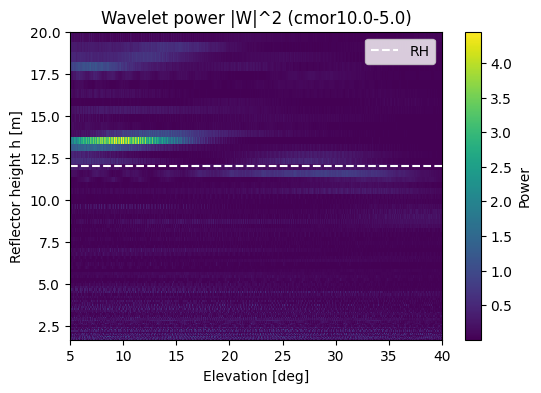

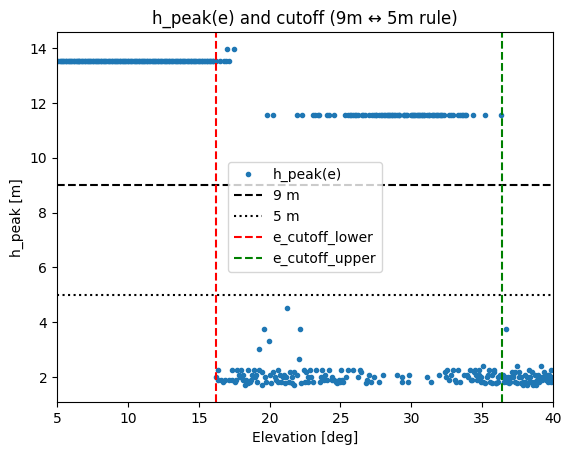

e_cutoff_lower, upper: 16.1824 36.372
RH_ref: 12.0


In [24]:
from gnssrefl.cutoff_swh import (
    load_snr_station,
    split_into_passes,
    process_single_pass,
)

df_snr = load_snr_station(
    base_dir="/etc/gnssrefl/refl_code",
    year=2020,
    station="calc",
    snr_column="L1",
    snr_type="88", 
)

passes = split_into_passes(df_snr, e_min=5.0, e_max=40.0)
p = passes[4]

res = process_single_pass(
    p["e_deg"],
    p["snr_db"],
    wavelength=lam,
    h_min=0.5,
    h_max=20.0,
    num_h=150,
    rh_input=12,
    plot=True,
    # どちらか1つの指定方法を使う：

    # 1) wavelet 名をそのまま渡す
    wavelet_name="cmor10.0-5.0",

    # 2) cmor_bandwidth / cmor_center から組み立てさせる場合は
    # wavelet_name=None,
    # cmor_bandwidth=3.0,
    # cmor_center=1.0,
)

print("e_cutoff_lower, upper:", res["e_cutoff_lower"], res["e_cutoff_upper"])
print("RH_ref:", res["rh_ref"])


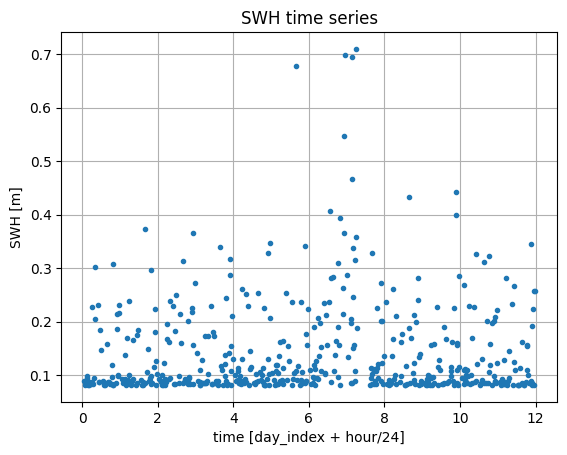

In [15]:
# SWH が NaN でないデータだけ
df_plot = df_swh.dropna(subset=["swh_m"]).copy()

# 連続時間軸: day_index + time_hour/24
df_plot["t_days"] = df_plot["day_index"] + df_plot["time_hour"] / 24.0

plt.plot(df_plot["t_days"], df_plot["swh_m"], "o", markersize=3)
plt.xlabel("time [day_index + hour/24]")
plt.ylabel("SWH [m]")
plt.title("SWH time series")
plt.grid(True)
plt.show()

day_index = 0


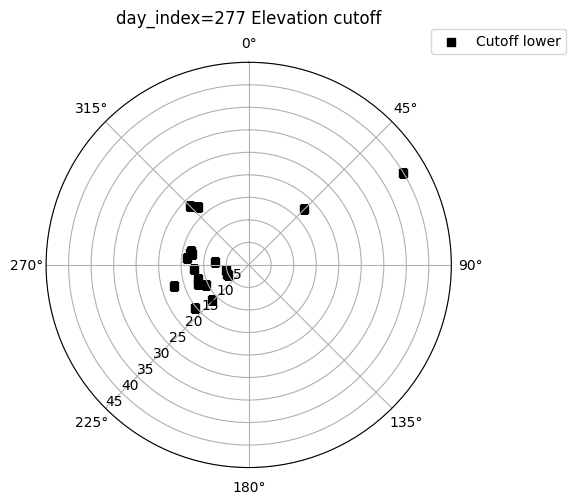

day_index = 1


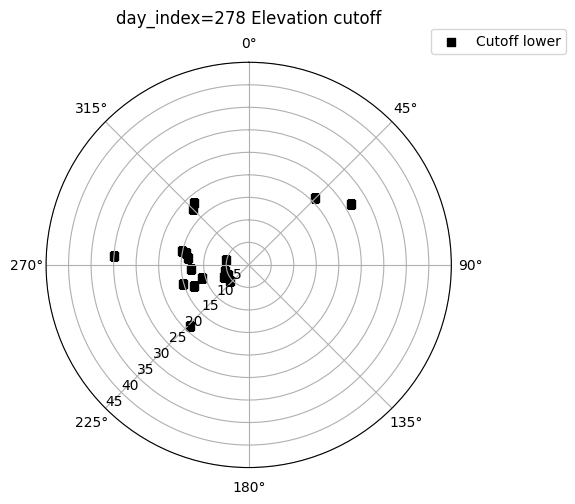

day_index = 2


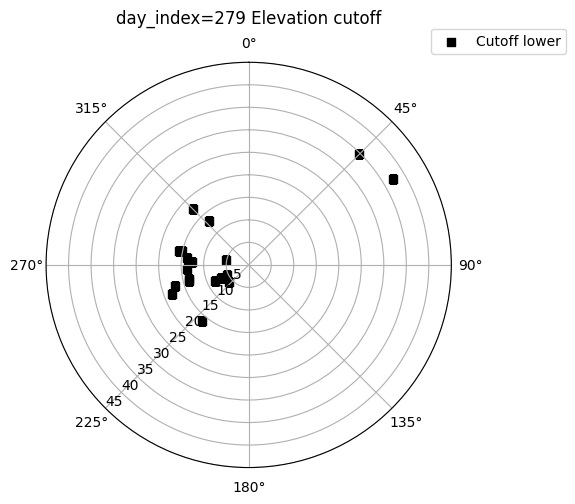

day_index = 3


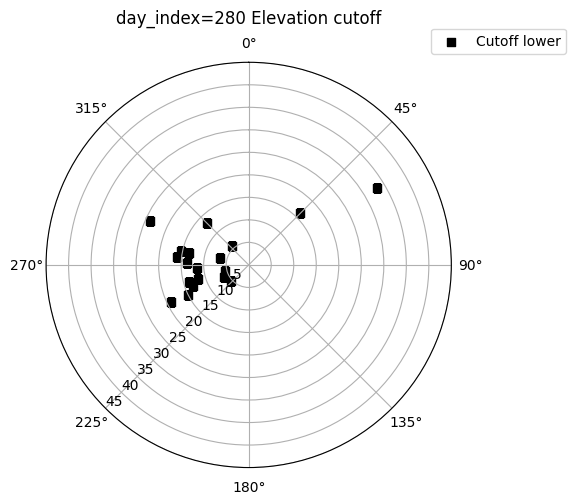

day_index = 4


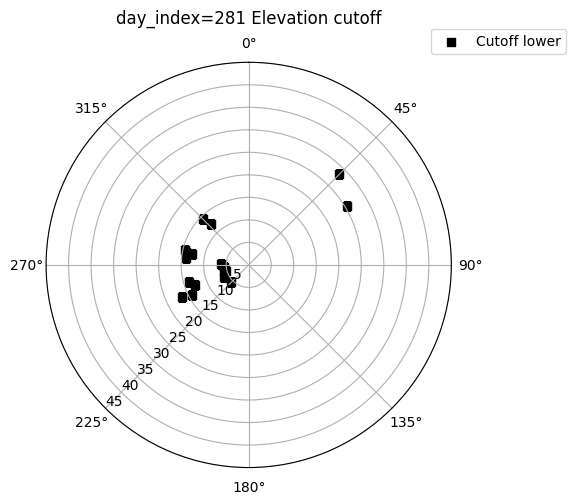

day_index = 5


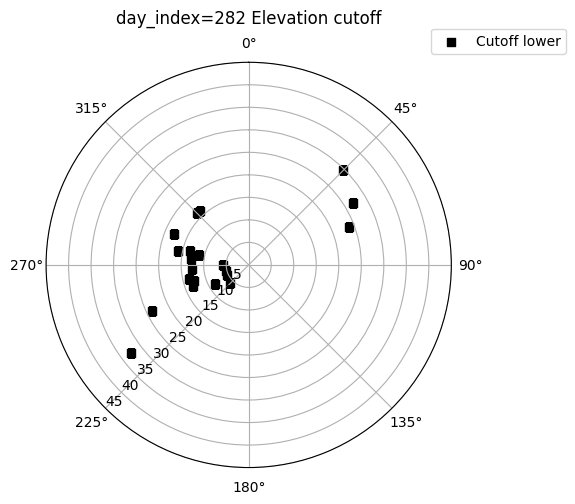

day_index = 6


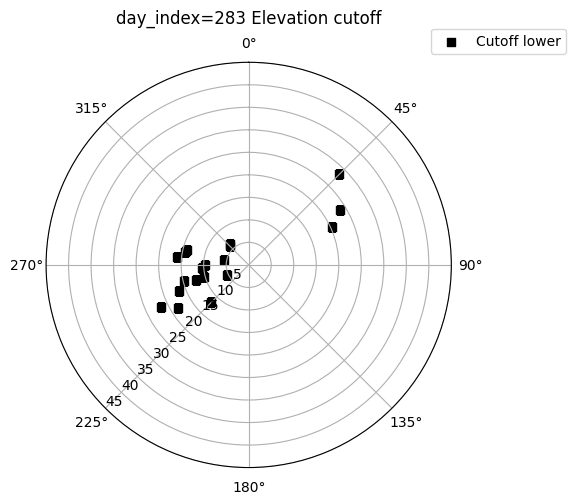

day_index = 7


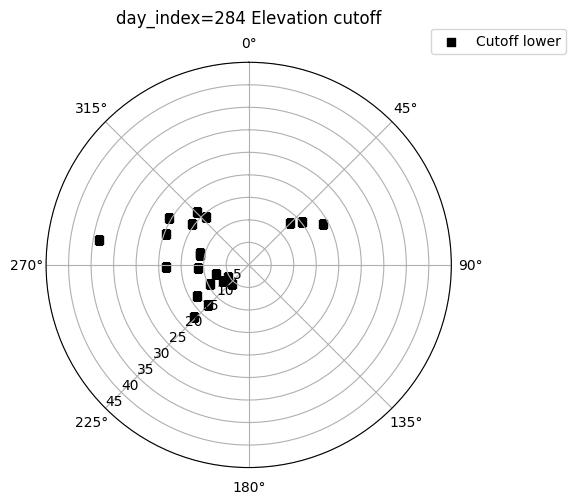

day_index = 8


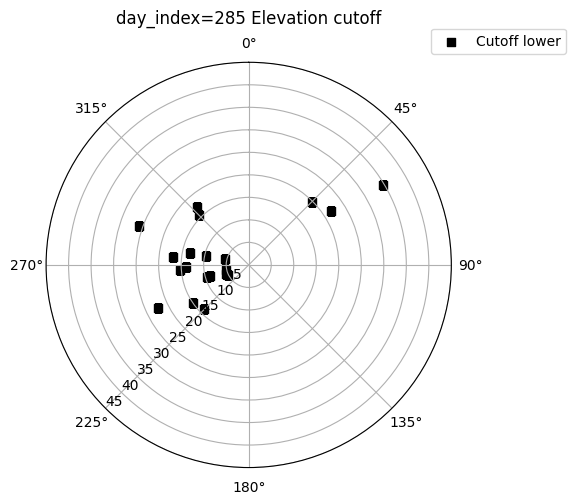

day_index = 9


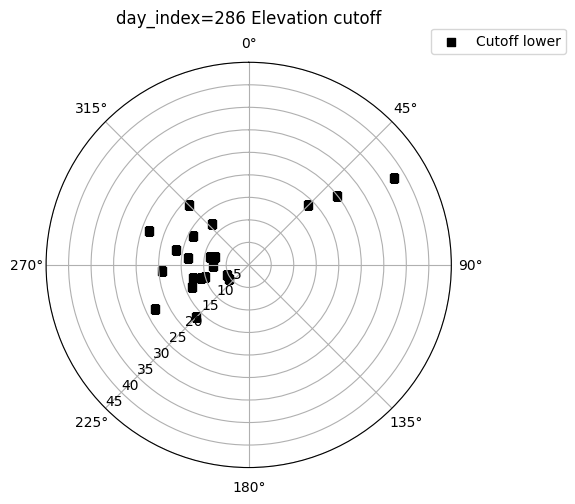

day_index = 10


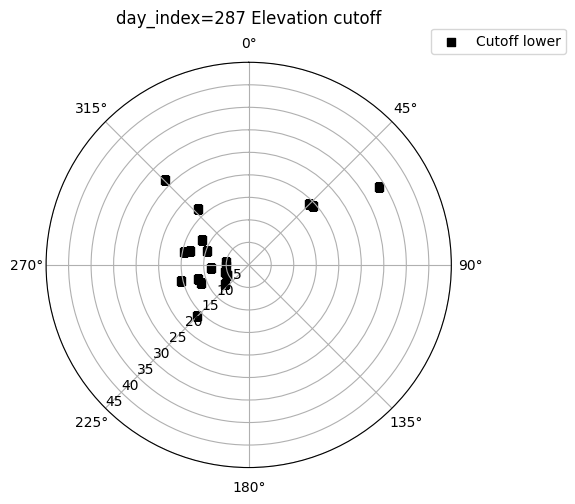

day_index = 11


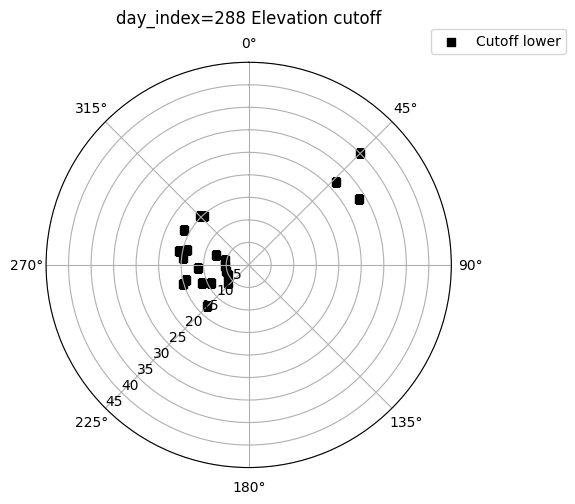

In [16]:
# 例: 270〜360度と 0〜60度を両方使う
az_mask = [(220, 70)]   # min>max の場合は [270,360]∪[0,60] の扱い

for day, sdf in df_swh.groupby("day_index"):
    try:
        print(f"day_index = {day}")
        plot_wind_polar(
            sdf,
            wind_speed=None,
            fig_path=None,
            title_prefix=f"day_index={277+day} ",
            show=True,
            az_mask=az_mask,
            r_max_fixed=45.0,
            enable_ellipse=False,    # 楕円フィットを描かない
            enable_direction=False,  # 風向推定＋青矢印も出さない
        )
    except ValueError as e:
        print(f"  skipped: {e}")


## Analysis of daily data in multiple data
**Extra Credit:**

The <code>gnssir</code> output tells you the vertical distance between the GPS antenna and 
the lake for each successful satellite track. That is not 
super exciting; it is a little more interesting to see if it changes over time, which means 
you need to analyze a bit more data. 

* use <code>rinex2snr</code> to make SNR files for the same year, but now do doy 120 through 290. You can use the <code>doy_end</code> parameter to do that. And use <code>weekly=True</code> to make fewer files (which will make everything much faster). Why did I pick those dates? Mostly to avoid snow (yeap, it snows up there!) 

In [ ]:
doy = 120
doy_end = 290

rinex2snr(station, year, doy=doy, doy_end=doy_end, weekly=True)

* run <code>gnssir</code> for those dates. You do not need the weekly option here - you can just specify 120 through 290. It will look for every day, but if it doesn't find it, it just looks for the next day, etc.

In [ ]:
# station, year, doy, and doy_end variables are already set.
gnssir(station, year, doy, doy_end=doy_end, screenstats=False)

* You can now use the <code>daily_avg</code> to make a daily average for the lake level on each day you analyzed.  

In [ ]:
daily_avg?

In [ ]:
daily_avg(station, medfilter=.25, ReqTracks=20, txtfile=f'{station}-dailyavg.txt')

# set a variable to where the file is saved
dailyavg_filepath = f'{refl_code_loc}/Files/{station}-dailyavg.txt'

* Let's plot the daily average file on each day analyzed. You can use the function read_rh_files from the gnssrefl_helpers module to read in the file.

In [ ]:
data = gnssrefl_helpers.read_rh_files(dailyavg_filepath)
# set data to pandas dataframe
df = pd.DataFrame(data, index=None, columns=['dates', 'rh'])
df.head()

In [ ]:
# Now plot
plt.figure(figsize=(8, 8))
g = sns.scatterplot(x='dates', y='rh', data=df, legend=False)
g.set_title('Ross Daily Mean Reflector Height')
g.set_ylabel('Reflector Height (m)')
g.set_ylim(4.55, 4.26)  # flip y axis so so 'up' is water levels rising
plt.show()

**Extra Extra Credit:**

Compare your results with the [lake gauge data.](https://www.isdm-gdsi.gc.ca/isdm-gdsi/twl-mne/inventory-inventaire/sd-ds-eng.asp?no=10220&user=isdm-gdsi&region=CA)